In [1]:
# 导入工具包
from detection.datasets import pascal_voc
import matplotlib.pyplot as plt
import numpy as np
from detection.models.detectors import faster_rcnn
import tensorflow as tf
import visualize
from detection.core.bbox import transforms

/opt/anaconda3/envs/dlcv/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
/opt/anaconda3/envs/dlcv/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
/opt/anaconda3/envs/dlcv/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
/opt/anaconda3/envs/dlcv/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
/opt/anaconda3/envs/dlcv/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed

# 数据模型加载

## 数据加载

In [2]:
pascal = pascal_voc.pascal_voc("train")
image,imagemeta,bbox,label = pascal[8]

In [4]:
image.shape

(1, 1024, 1024, 3)

In [3]:
# 均值
# 图像的均值和标准差
img_mean = (122.7717, 115.9465, 102.9801)
img_std = (1., 1., 1.)

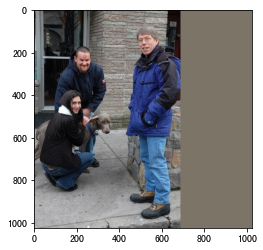

In [5]:
rgd_image= np.round(image+img_mean).astype(np.uint8)
plt.imshow(rgd_image[0])
plt.show()

## 模型加载

In [6]:
# coco数据集的class
classes = ['bg', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
           'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
model = faster_rcnn.FasterRCNN(num_classes=len(classes))

In [7]:
model((image,imagemeta,bbox,label),training=True)

[<tf.Tensor: shape=(), dtype=float32, numpy=18.79203>,
 <tf.Tensor: shape=(), dtype=float32, numpy=3.3609345>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4.8089595>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.53403777>]

In [8]:
# 加载训练好的weights
model.load_weights("weights/faster_rcnn.h5")

# RPN

## 目标值

In [9]:
# 产生anchor
anchors,valid_flags = model.rpn_head.generator.generate_pyramid_anchors(imagemeta)

In [10]:
anchors.numpy().shape

(261888, 4)

In [11]:
# 获取对应的目标值
rpn_target_matchs,rpn_target_deltas = model.rpn_head.anchor_target.build_targets(anchors,valid_flags,bbox,label)

In [12]:
rpn_target_matchs.numpy().shape

(1, 261888)

In [13]:
rpn_target_deltas.numpy().shape

(1, 256, 4)

In [14]:
positive_anchors = tf.gather(anchors,tf.where(tf.equal(rpn_target_matchs,1))[:,1])

In [15]:
positive_anchors.numpy().shape

(4, 4)

In [16]:
negtivate_anchors = tf.gather(anchors,tf.where(tf.equal(rpn_target_matchs,-1))[:,1])

In [17]:
negtivate_anchors.numpy().shape

(252, 4)

In [18]:
netural_anchors = tf.gather(anchors,tf.where(tf.equal(rpn_target_matchs,0))[:,1])

In [19]:
netural_anchors.numpy().shape

(261632, 4)

In [20]:
# 获取网络的输出值:对anchor的偏移和尺度
positive_target_deltas = rpn_target_deltas[0,:tf.where(tf.equal(rpn_target_matchs,1)).shape[0]]

In [24]:
# 对anchor修正后的结果
refines_box = transforms.delta2bbox(positive_anchors,positive_target_deltas,(0.,0.,0.,0.),(0.1,0.1,0.2,0.2))

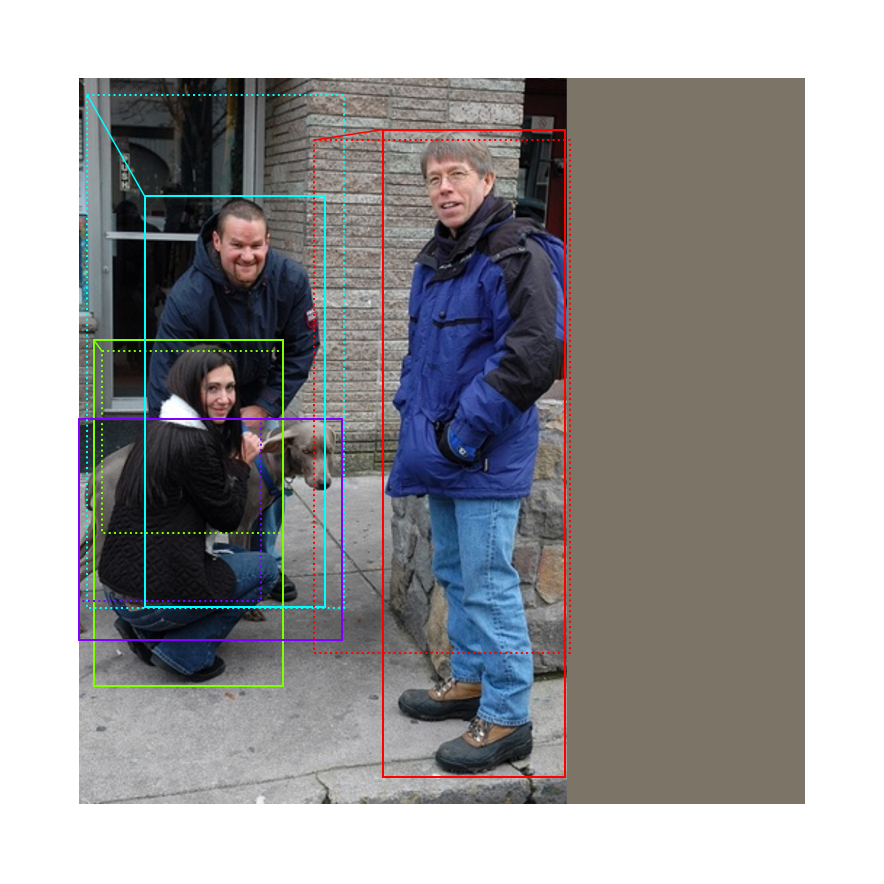

In [25]:
# 显示
visualize.draw_boxes(rgd_image[0],positive_anchors.numpy(),refined_boxes=refines_box.numpy())
plt.show()

## RPN预测

In [26]:
# 使用backbone获取特征图
C2,C3,C4,C5 = model.backbone(image,training=False)

In [27]:
# FCN网络融合
P2,P3,P4,P5,P6 = model.neck([C2,C3,C4,C5],training=False)

In [28]:
# RPN网络的输入
rpn_feature_maps = [P2,P3,P4,P5,P6]

In [29]:
# RPN网络预测
rpn_class_logits,rpn_probs,rpn_deltas = model.rpn_head(rpn_feature_maps,training = False)

In [30]:
rpn_class_logits.numpy().shape

(1, 261888, 2)

In [31]:
rpn_probs.numpy().shape

(1, 261888, 2)

In [32]:
rpn_deltas.numpy().shape

(1, 261888, 4)

In [33]:
# 获取分类score较高的这些
rpn_probs_tmp = rpn_probs[0,:,1]

In [34]:
rpn_probs_tmp.numpy().shape

(261888,)

In [36]:
# 获取前100个较高的anchor
limit = 100
ix = tf.nn.top_k(rpn_probs_tmp,k=limit).indices[::-1]

In [38]:
ix

<tf.Tensor: shape=(100,), dtype=int32, numpy=
array([248655, 259696, 258931, 258967, 253110, 259347, 258966, 258934,
       261514, 259981, 249912, 259792, 261613, 252915, 261516, 259731,
       253260, 253638, 259884, 249036, 258873, 259350, 259635, 259446,
       261432, 249426, 259801, 259791, 252873, 259539, 261321, 259030,
       252726, 259899, 259980, 259254, 259062, 261672, 249042, 259887,
       252870, 261565, 258970, 259158, 259027, 252918, 259443, 259066,
       259123, 261576, 261627, 253449, 259126, 249339, 260079, 259897,
       249336, 261579, 259065, 258969, 261339, 261624, 249234, 259257,
       249423, 261387, 261609, 261465, 249720, 261370, 248847, 259983,
       253446, 259161, 261655, 259803, 249915, 249528, 261561, 261528,
       253257, 249531, 253065, 261513, 261480, 249723, 261558, 249039,
       261606, 253254, 253062, 249231, 261510, 261531, 261435, 261610,
       261559, 261562, 261483, 261607], dtype=int32)>

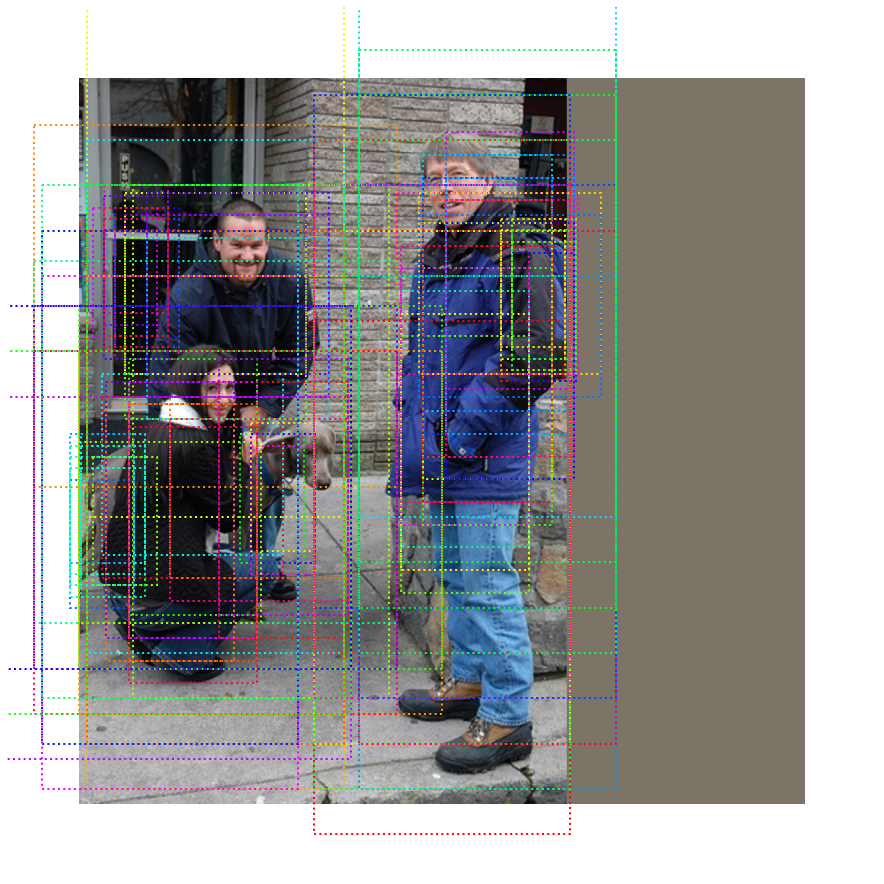

In [39]:
visualize.draw_boxes(rgd_image[0],tf.gather(anchors,ix).numpy())

# FastRCNN 预测

In [40]:
# 获取输入特征图
rcnn_feature_maps = [P2,P3,P4,P5]

In [41]:
# 获取候选区域
proposals_list = model.rpn_head.get_proposals(rpn_probs,rpn_deltas,imagemeta)

In [48]:
proposals_list

[<tf.Tensor: shape=(1603, 4), dtype=float32, numpy=
 array([[0.4001273 , 0.01325157, 0.834808  , 0.3224837 ],
        [0.08705094, 0.42151093, 0.87980497, 0.6767225 ],
        [0.16959521, 0.04361809, 0.39528587, 0.11909449],
        ...,
        [0.19331731, 0.15701705, 0.21243009, 0.17830145],
        [0.2774249 , 0.09819024, 0.30442834, 0.1178089 ],
        [0.64521986, 0.19173   , 0.66536766, 0.24908559]], dtype=float32)>]

In [49]:
# ROI Pooling
pool_region_list = model.roi_align((proposals_list,rcnn_feature_maps,imagemeta),training = False)

In [50]:
pool_region_list

[<tf.Tensor: shape=(1603, 7, 7, 256), dtype=float32, numpy=
 array([[[[-2.53967285e+00,  2.56740236e+00,  1.84821486e-01, ...,
           -7.67262220e-01, -7.44047403e-01, -2.44104552e+00],
          [-2.23786306e+00, -9.60459352e-01,  1.69775403e+00, ...,
           -2.39230990e+00, -4.20697975e+00, -1.86287069e+00],
          [ 9.49685574e-01, -2.63504696e+00,  2.49073339e+00, ...,
            1.59789646e+00, -6.16778231e+00,  3.02135992e+00],
          ...,
          [ 8.89666939e+00, -3.26939297e+00,  2.18688178e+00, ...,
            6.85320282e+00,  1.18318856e+00, -1.16335344e+00],
          [ 2.04727101e+00, -5.74842453e+00,  3.05480696e-02, ...,
            4.86994076e+00,  3.65649319e+00, -2.81425953e+00],
          [-7.35873795e+00, -1.92674959e+00,  2.38051367e+00, ...,
            2.91400146e+00,  2.82309937e+00, -1.72433078e-01]],
 
         [[-1.86193764e-01,  2.97297239e-02,  7.34028459e-01, ...,
           -1.18686903e+00, -3.05472565e+00, -2.19658089e+00],
          [ 

In [51]:
# RCNN网络的预测
rcnn_class_logits,rcnn_class_probs,rcnn_deltas_list = model.bbox_head(pool_region_list,training=False)

In [52]:
# 获取预测结果
detection_list = model.bbox_head.get_bboxes(rcnn_class_probs,rcnn_deltas_list,proposals_list,imagemeta)

In [53]:
detection_list

[<tf.Tensor: shape=(7, 6), dtype=float32, numpy=
 array([[7.84094543e+01, 4.25007446e+02, 9.76828613e+02, 6.81562256e+02,
         1.00000000e+00, 9.99940872e-01],
        [1.72356430e+02, 8.57876358e+01, 4.98395691e+02, 3.40631226e+02,
         1.00000000e+00, 9.98795509e-01],
        [3.71934753e+02, 2.51599426e+01, 8.43243469e+02, 2.93213318e+02,
         1.00000000e+00, 9.92524803e-01],
        [4.80616974e+02, 2.16215271e+02, 7.11912109e+02, 3.55624695e+02,
         1.70000000e+01, 9.89203036e-01],
        [1.70404816e+02, 4.73387489e+01, 4.10206665e+02, 1.20774796e+02,
         1.00000000e+00, 9.80532765e-01],
        [1.98444153e+02, 5.67865601e+02, 4.13658264e+02, 6.85466309e+02,
         2.50000000e+01, 9.70609367e-01],
        [5.12909546e+02, 5.18211365e-01, 7.44110657e+02, 8.44367828e+01,
         2.10000000e+01, 7.49150932e-01]], dtype=float32)>]

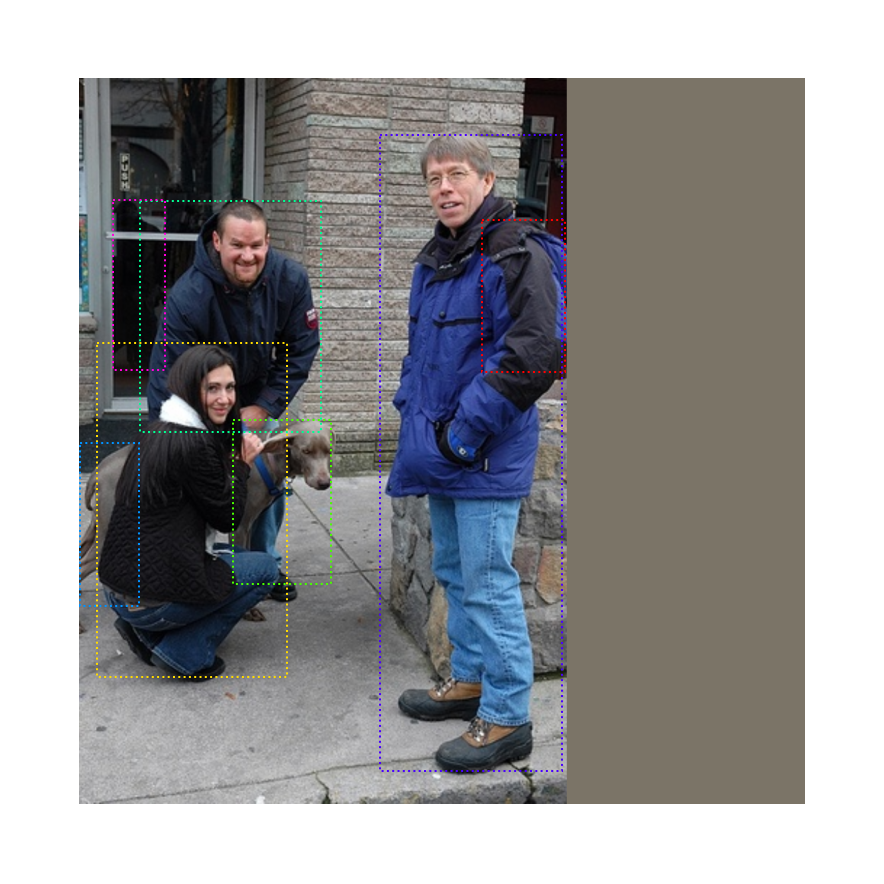

In [54]:
# 绘制在图像上
visualize.draw_boxes(rgd_image[0],boxes=detection_list[0][:,:4])
plt.show()

# 直接进行检测

In [56]:
# 获取候选区域
proposals = model.simple_test_rpn(image[0],imagemeta[0])

In [57]:
proposals

<tf.Tensor: shape=(1603, 4), dtype=float32, numpy=
array([[0.4001273 , 0.01325157, 0.834808  , 0.3224837 ],
       [0.08705094, 0.42151093, 0.87980497, 0.6767225 ],
       [0.16959521, 0.04361809, 0.39528587, 0.11909449],
       ...,
       [0.19331731, 0.15701705, 0.21243009, 0.17830145],
       [0.2774249 , 0.09819024, 0.30442834, 0.1178089 ],
       [0.64521986, 0.19173   , 0.66536766, 0.24908559]], dtype=float32)>

In [58]:
# rcnn进行预测
res = model.simple_test_bboxes(image[0],imagemeta[0],proposals)

In [59]:
res

{'rois': array([[3.8285866e+01, 2.0752316e+02, 4.7696707e+02, 3.3279407e+02],
        [8.4158409e+01, 4.1888493e+01, 2.4335725e+02, 1.6632384e+02],
        [1.8160876e+02, 1.2285128e+01, 4.1173996e+02, 1.4317056e+02],
        [2.3467624e+02, 1.0557386e+02, 3.4761331e+02, 1.7364487e+02],
        [8.3205475e+01, 2.3114622e+01, 2.0029622e+02, 5.8972065e+01],
        [9.6896553e+01, 2.7727811e+02, 2.0198157e+02, 3.3470032e+02],
        [2.5044411e+02, 2.5303289e-01, 3.6333527e+02, 4.1228897e+01]],
       dtype=float32),
 'class_ids': array([ 1,  1,  1, 17,  1, 25, 21], dtype=int32),
 'scores': array([0.9999409 , 0.9987955 , 0.9925248 , 0.98920304, 0.98053277,
        0.97060937, 0.74915093], dtype=float32)}

In [60]:
# 获取原始图像
from detection.datasets.utils import get_original_image

In [61]:
ori_img = get_original_image(image[0],imagemeta[0],img_mean)

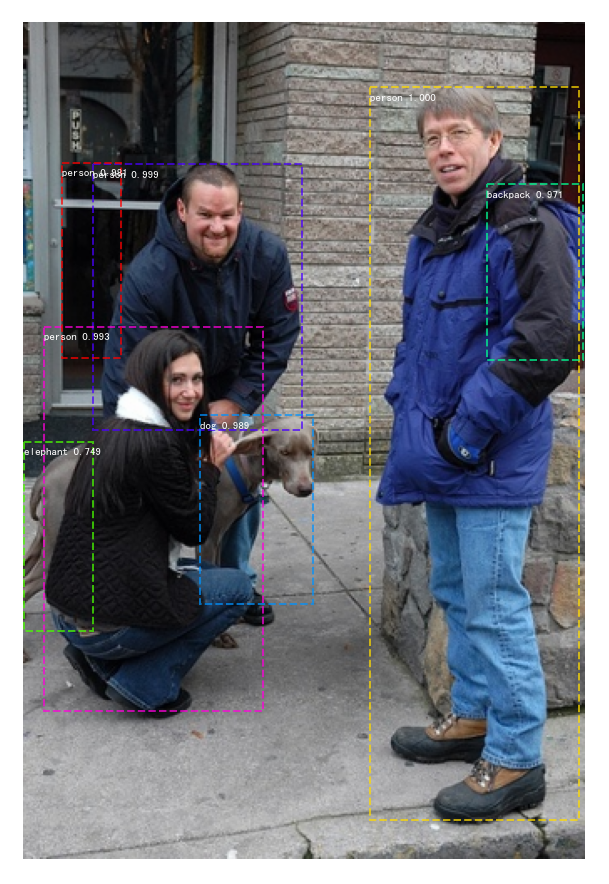

In [62]:
# 将检测结果绘制在图像上
visualize.display_instances(ori_img,res['rois'],res['class_ids'],classes,res['scores'])
plt.show()